In [1]:
# -*- coding: utf-8 -*-
"""
Комплексне дослідження датасету ожиріння (Obesity Dataset)
Аналіз від експерта з охорони здоров'я та дієтології
(Адаптовано для Google Colab)
"""

# =============================================================================
# 1. ІМПОРТ БІБЛІОТЕК
# =============================================================================
# Імпортуємо основні бібліотеки для маніпуляцій з даними, візуалізації та моделювання
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Статистичні тести для перевірки гіпотез
from scipy.stats import spearmanr, chi2_contingency, f_oneway, kruskal

# Бібліотеки машинного навчання від scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore') # Ігноруємо попередження для чистоти виводу

# Налаштовуємо стиль графіків для кращої читабельності
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:


# =============================================================================
# 2. ЗАВАНТАЖЕННЯ ДАНИХ
# =============================================================================
# Підключаємо Google Drive (якщо дані зберігаються там)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Завантажуємо датасет.
# Примітка: файл 'obesity_dataset_enhanced.csv' має містити попередньо оброблені ознаки
file_path = '/content/drive/MyDrive/Machine_Learning/HealthCare_/Obesity_risk/obesity_dataset_enhanced.csv'
df = pd.read_csv(file_path)

print(f"Розмірність датасету: {df.shape} (рядки, стовпці)")
print("\nПерші 5 рядків датасету:")
display(df.head())


Mounted at /content/drive
Розмірність датасету: (2086, 19) (рядки, стовпці)

Перші 5 рядків датасету:


,Height,Weight,BMI,Gender,Age,SMOKE,MTRANS,family_history_with_overweight,SCC,FAVC_z,FCVC_minmax,NCP_z,CAEC_minmax,CH2O_minmax,FAF_minmax,TUE_z,CALC_z,Age_bin_minmax,NObeyesdad
0,1.62,64.0,24.386526,Male,33.5,0,Automobile,1,0,2.766876,0.5,0.404704,0.333333,0.5,0.000000,0.550985,1.439033,0.25,1
1,1.52,56.0,24.238227,Female,33.5,0,Bike,1,1,2.766876,1.0,0.404704,0.333333,1.0,1.000000,1.092724,0.516552,0.25,1
2,1.80,77.0,23.765432,Female,49.0,1,Public_Transport,1,0,2.766876,0.5,0.404704,0.333333,0.5,0.666667,0.550985,2.472136,0.50,1
3,1.80,87.0,26.851852,Female,64.5,0,Walking,0,0,2.766876,1.0,0.404704,0.333333,0.5,0.666667,1.092724,2.472136,0.75,2
4,1.78,89.8,28.342381,Male,49.0,0,Public_Transport,0,0,2.766876,0.5,2.164116,0.333333,0.5,0.000000,1.092724,0.516552,0.50,3


In [3]:

# =============================================================================
# 3. ПОПЕРЕДНЯ ОБРОБКА ТА ОЧИЩЕННЯ ДАНИХ
# =============================================================================
# Перевіряємо наявність пропущених значень
print("\nКількість пропущених значень у кожній колонці:")
print(df.isnull().sum())

# Перевіряємо типи даних
print("\nТипи даних у стовпцях:")
print(df.dtypes)

# Перетворюємо категоріальні змінні на відповідний тип 'category' для економії пам'яті
# ВАЖЛИВО: Цільову змінну NObeyesdad НЕ переводимо в category, щоб уникнути помилок
# при математичних порівняннях (наприклад, >= 4). Замість цього створимо окрему колонку.
categorical_cols = ['Gender', 'SMOKE', 'MTRANS', 'family_history_with_overweight', 'SCC']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Перевіряємо наявність дублікатів
print(f"\nКількість повних дублікатів рядків: {df.duplicated().sum()}")

# Створюємо зручний псевдонім для цільової змінної (клас ожиріння) як категорію для графіків
df['Obesity_Class'] = df['NObeyesdad'].astype('category')



Кількість пропущених значень у кожній колонці:
Height                            0
Weight                            0
BMI                               0
Gender                            0
Age                               0
SMOKE                             0
MTRANS                            0
family_history_with_overweight    0
SCC                               0
FAVC_z                            0
FCVC_minmax                       0
NCP_z                             0
CAEC_minmax                       0
CH2O_minmax                       0
FAF_minmax                        0
TUE_z                             0
CALC_z                            0
Age_bin_minmax                    0
NObeyesdad                        0
dtype: int64

Типи даних у стовпцях:
Height                            float64
Weight                            float64
BMI                               float64
Gender                             object
Age                               float64
SMOKE                

In [9]:
print(df.columns.tolist())

['Height', 'Weight', 'BMI', 'Gender', 'Age', 'SMOKE', 'MTRANS', 'family_history_with_overweight', 'SCC', 'FAVC_z', 'FCVC_minmax', 'NCP_z', 'CAEC_minmax', 'CH2O_minmax', 'FAF_minmax', 'TUE_z', 'CALC_z', 'Age_bin_minmax', 'NObeyesdad', 'Obesity_Class', 'obese_bin', 'FAF_bin', 'Age_bin']


In [11]:
print(df['Obesity_Class'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 2086 entries, 0 to 2085
Series name: Obesity_Class
Non-Null Count  Dtype   
--------------  -----   
2086 non-null   category
dtypes: category(1)
memory usage: 2.5 KB
None


In [12]:
print(df['Obesity_Class'].value_counts())

Obesity_Class
4    342
6    323
5    297
2    289
1    285
3    278
0    272
Name: count, dtype: int64



Розподіл класів ожиріння (NObeyesdad):
Obesity_Class
0    272
1    285
2    289
3    278
4    342
5    297
6    323
Name: count, dtype: int64


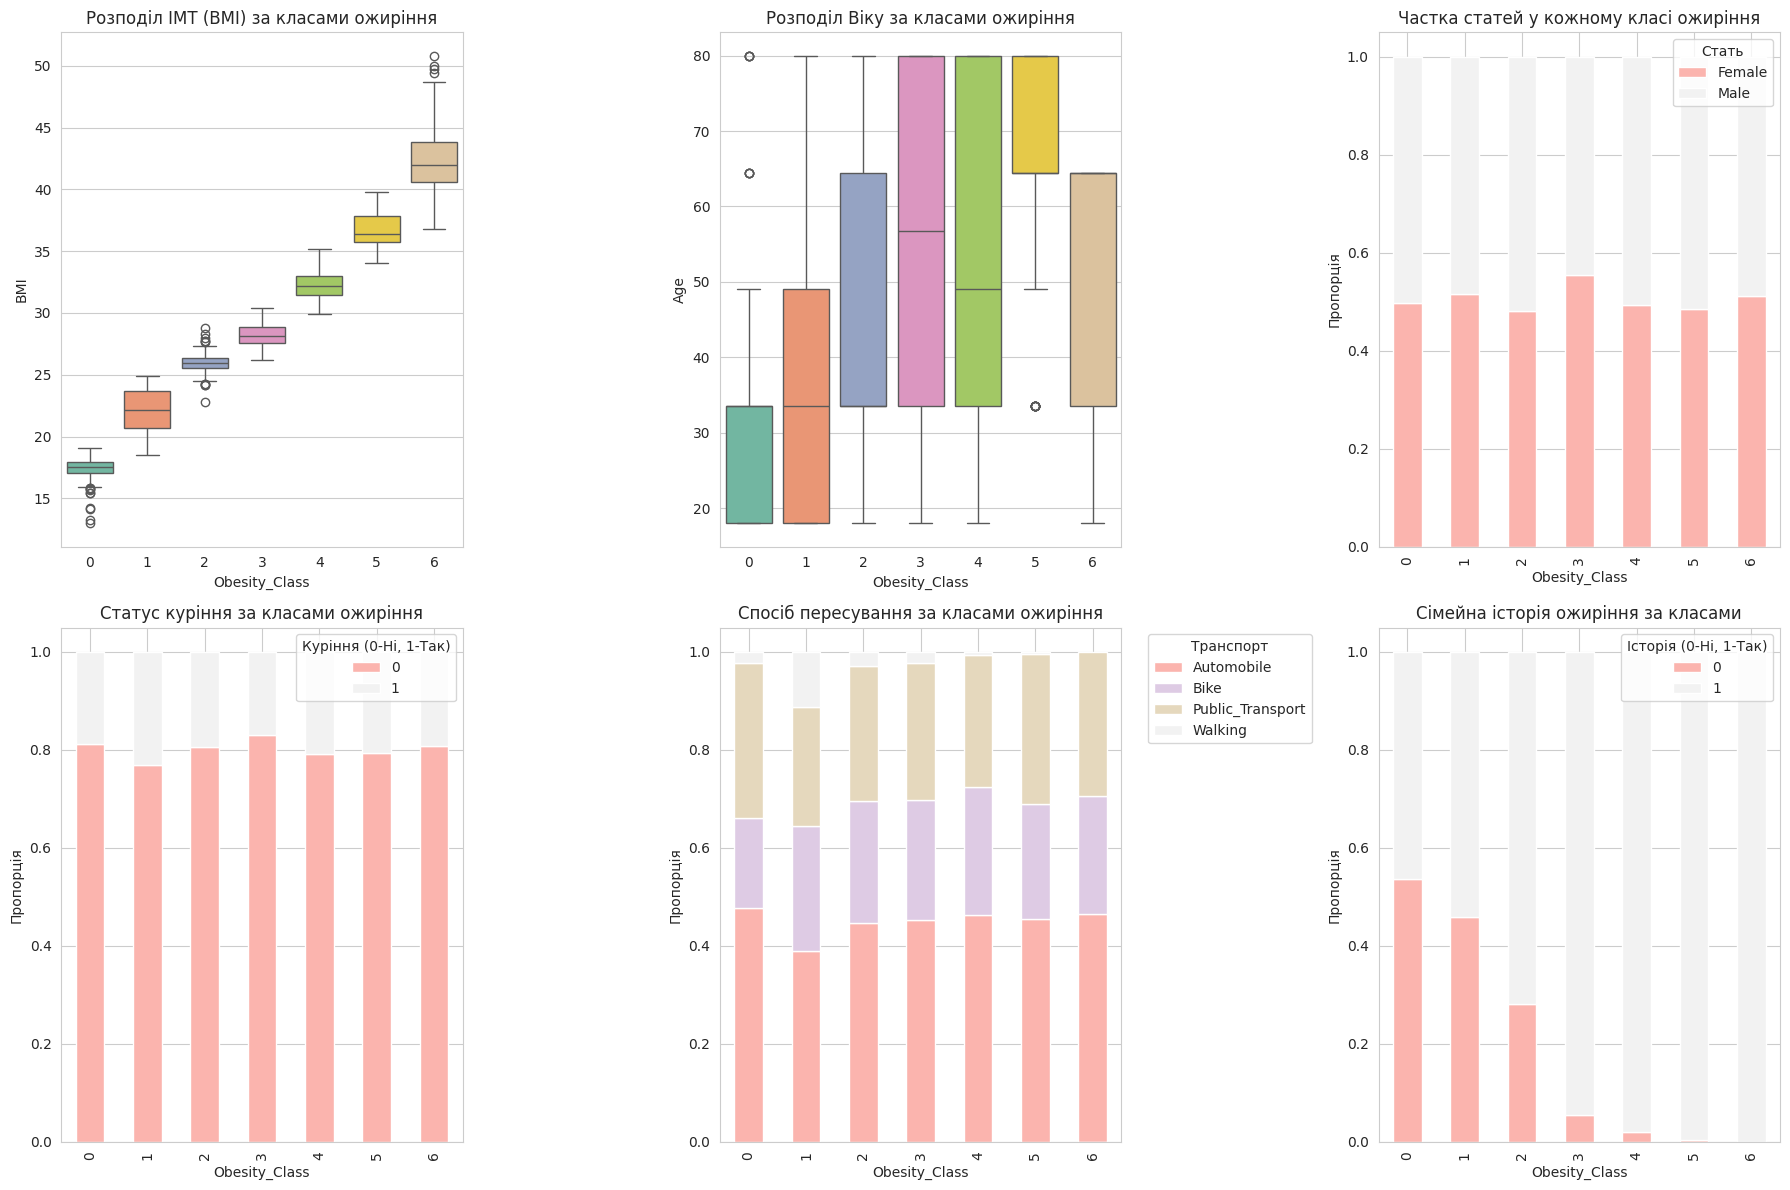


Середні значення числових ознак за класами ожиріння:


,Height,Weight,BMI,Age,FAVC_z,FCVC_minmax,NCP_z,CAEC_minmax,CH2O_minmax,FAF_minmax,TUE_z,CALC_z
Obesity_Class,,,,,,,,,,,,
0,1.69,49.91,17.40,30.42,0.81,0.74,1.00,0.48,0.44,0.42,0.93,0.92
1,1.68,62.18,22.01,37.96,1.02,0.66,0.86,0.50,0.42,0.42,1.00,0.99
2,1.69,74.23,25.99,44.66,0.54,0.63,1.00,0.32,0.53,0.35,0.98,0.78
3,1.70,82.07,28.20,55.63,0.99,0.63,0.76,0.36,0.52,0.32,0.81,1.03
4,1.70,93.20,32.28,51.18,0.43,0.59,0.80,0.35,0.55,0.34,0.99,1.02
5,1.77,115.31,36.72,69.35,0.42,0.70,0.57,0.34,0.44,0.32,0.84,0.75
6,1.69,120.78,42.25,51.45,0.37,1.00,0.40,0.33,0.60,0.22,0.39,0.52


In [4]:

# =============================================================================
# 4. ОПИСОВИЙ ТА РОЗПОДІЛЬНИЙ АНАЛІЗ (EDA)
# =============================================================================
# 4.1 Розподіл класів ожиріння (перевірка на дисбаланс класів)
print("\nРозподіл класів ожиріння (NObeyesdad):")
print(df['Obesity_Class'].value_counts().sort_index())

# 4.2 - 4.7 Візуалізація розподілів основних ознак відносно класів ожиріння
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Boxplot для ІМТ (BMI) по класах
sns.boxplot(x='Obesity_Class', y='BMI', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Розподіл ІМТ (BMI) за класами ожиріння')

# Boxplot для Віку по класах
sns.boxplot(x='Obesity_Class', y='Age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Розподіл Віку за класами ожиріння')

# Стовпчасті діаграми часток (Stacked Bar) для категоріальних ознак
pd.crosstab(df['Obesity_Class'], df['Gender'], normalize='index').plot(kind='bar', stacked=True, ax=axes[2], colormap='Pastel1')
axes[2].set_title('Частка статей у кожному класі ожиріння')
axes[2].set_ylabel('Пропорція')
axes[2].legend(title='Стать')

pd.crosstab(df['Obesity_Class'], df['SMOKE'], normalize='index').plot(kind='bar', stacked=True, ax=axes[3], colormap='Pastel1')
axes[3].set_title('Статус куріння за класами ожиріння')
axes[3].set_ylabel('Пропорція')
axes[3].legend(title='Куріння (0-Ні, 1-Так)')

pd.crosstab(df['Obesity_Class'], df['MTRANS'], normalize='index').plot(kind='bar', stacked=True, ax=axes[4], colormap='Pastel1')
axes[4].set_title('Спосіб пересування за класами ожиріння')
axes[4].set_ylabel('Пропорція')
axes[4].legend(title='Транспорт', bbox_to_anchor=(1.05, 1))

pd.crosstab(df['Obesity_Class'], df['family_history_with_overweight'], normalize='index').plot(kind='bar', stacked=True, ax=axes[5], colormap='Pastel1')
axes[5].set_title('Сімейна історія ожиріння за класами')
axes[5].set_ylabel('Пропорція')
axes[5].legend(title='Історія (0-Ні, 1-Так)')

plt.tight_layout()
plt.show()

# 4.8 Зведена статистика (середні значення) числових ознак по класах
numeric_cols = ['Height', 'Weight', 'BMI', 'Age', 'FAVC_z', 'FCVC_minmax', 'NCP_z',
                'CAEC_minmax', 'CH2O_minmax', 'FAF_minmax', 'TUE_z', 'CALC_z']
print("\nСередні значення числових ознак за класами ожиріння:")
display(df.groupby('Obesity_Class')[numeric_cols].mean().round(2))

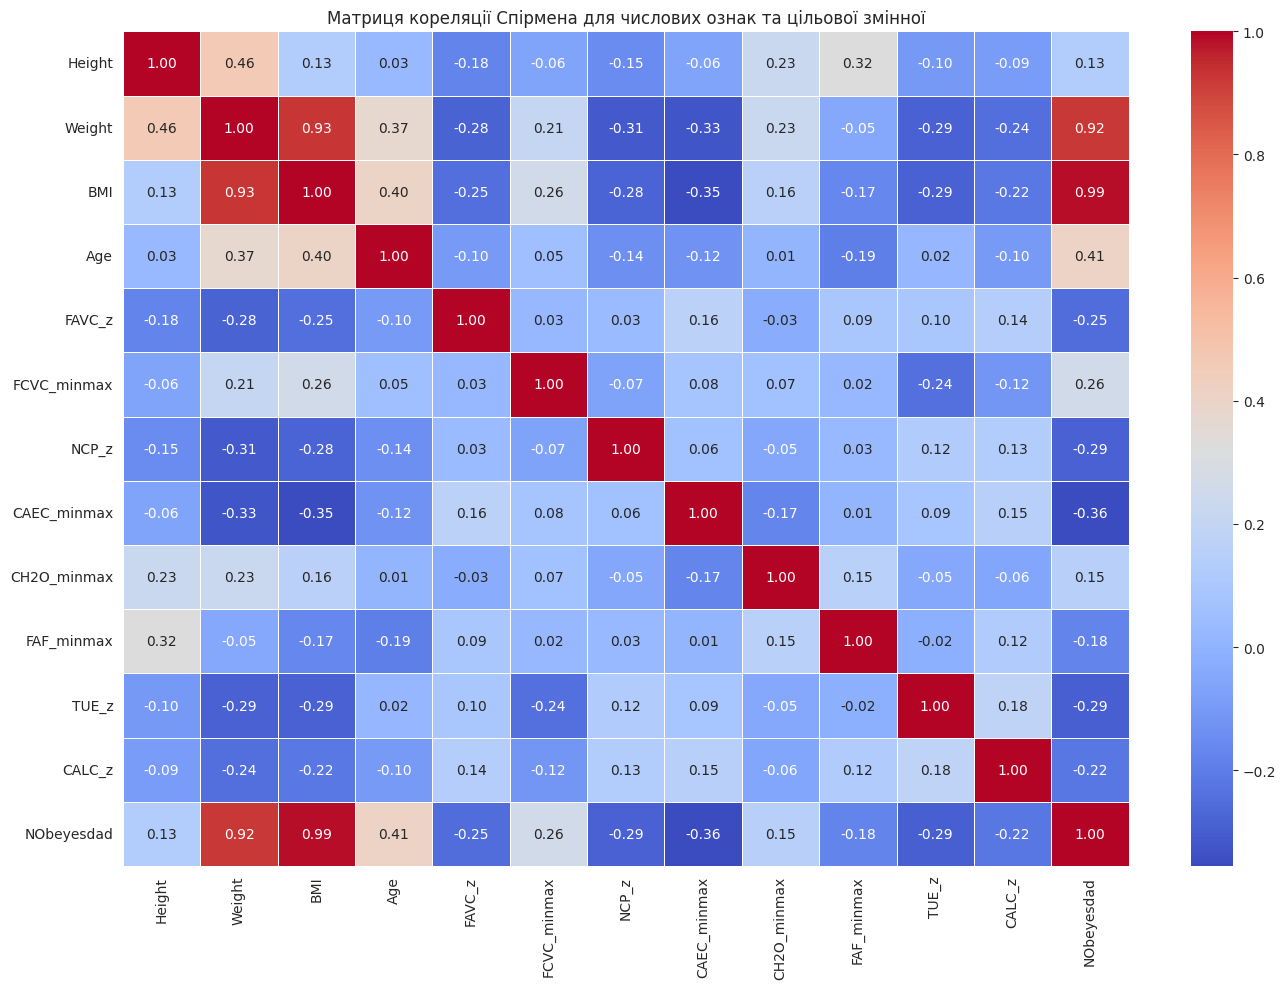

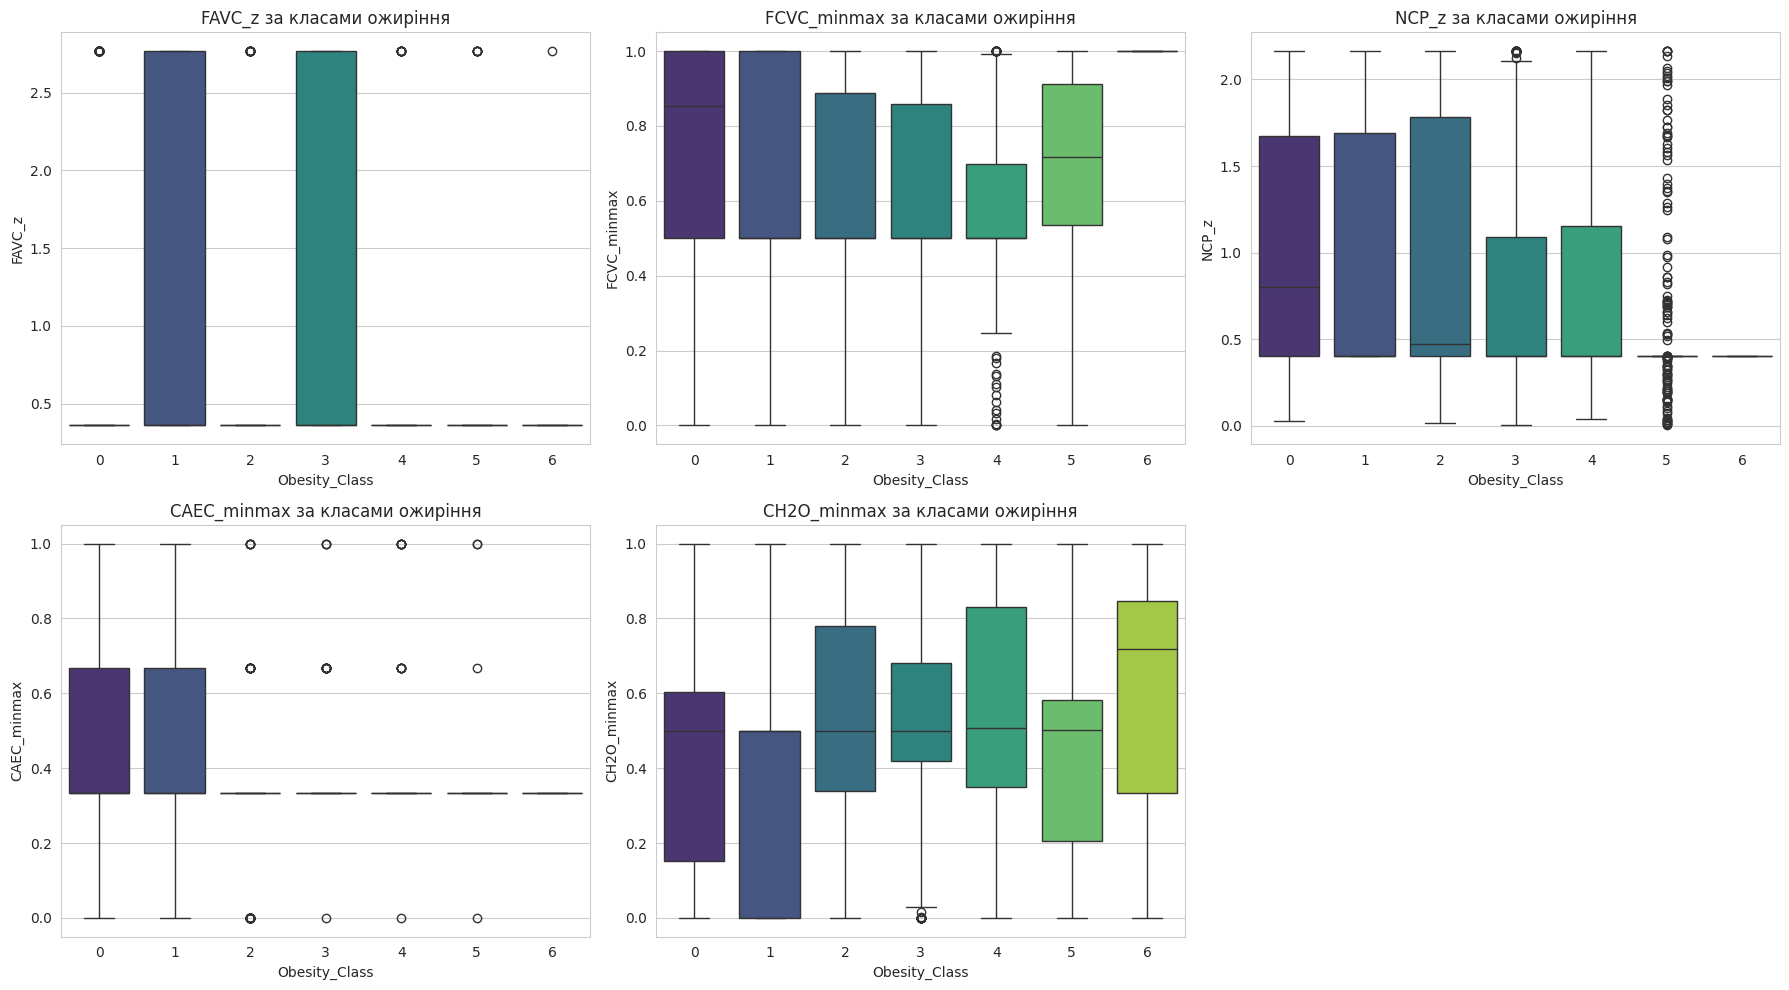

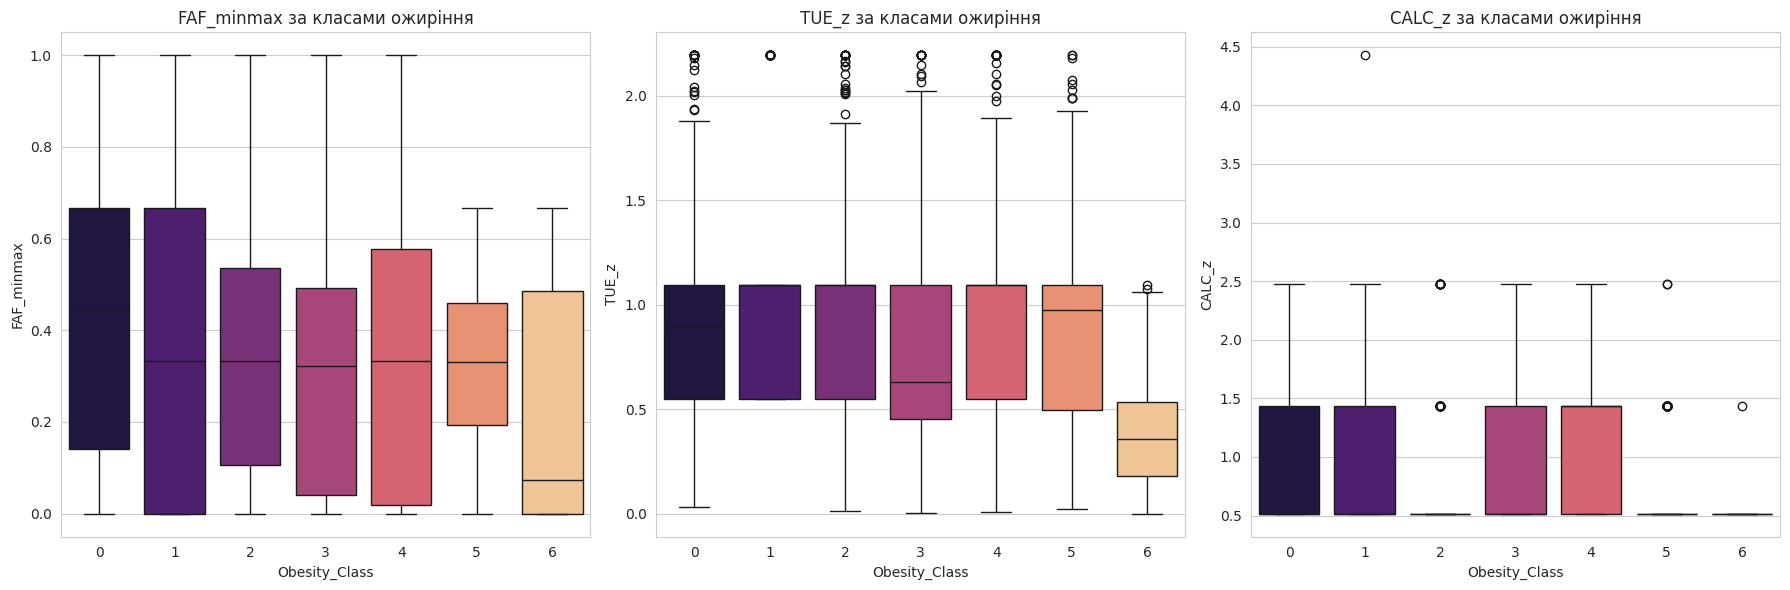


Статистичні тести (Крускала-Уолліса) для числових ознак:
Height         : H= 217.857, p-value=2.9790e-44
Weight         : H=1804.002, p-value=0.0000e+00
BMI            : H=2035.638, p-value=0.0000e+00
Age            : H= 567.367, p-value=2.5437e-119
FAVC_z         : H= 236.929, p-value=2.5404e-48
FCVC_minmax    : H= 647.283, p-value=1.4657e-136
NCP_z          : H= 195.141, p-value=2.0524e-39
CAEC_minmax    : H= 458.440, p-value=7.4881e-96
CH2O_minmax    : H=  94.902, p-value=2.8982e-18
FAF_minmax     : H=  87.761, p-value=8.8342e-17
TUE_z          : H= 399.300, p-value=3.9538e-83
CALC_z         : H= 278.514, p-value=3.2686e-57

Статистичні тести (Хі-квадрат) для категоріальних ознак:
Gender                             : chi2=   4.235, p-value=6.4493e-01
SMOKE                              : chi2=   4.076, p-value=6.6642e-01
MTRANS                             : chi2= 111.783, p-value=1.4640e-15
family_history_with_overweight     : chi2= 620.631, p-value=8.2612e-131
SCC                  

In [5]:


# =============================================================================
# 5. БІВАРІАТИВНИЙ АНАЛІЗ ТА СТАТИСТИЧНІ ТЕСТИ
# =============================================================================
# 5.1 Теплова карта кореляцій (Кореляція Спірмена, оскільки дані можуть бути порядковими)
plt.figure(figsize=(14, 10))
corr = df[numeric_cols + ['NObeyesdad']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матриця кореляції Спірмена для числових ознак та цільової змінної')
plt.tight_layout()
plt.show()

# 5.2 Boxplots для харчових звичок
dietary_features = ['FAVC_z', 'FCVC_minmax', 'NCP_z', 'CAEC_minmax', 'CH2O_minmax']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(dietary_features):
    sns.boxplot(x='Obesity_Class', y=feat, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{feat} за класами ожиріння')
# Ховаємо порожній subplot, якщо їх більше ніж ознак
if len(dietary_features) < len(axes):
    axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# 5.3 Boxplots для фізичної активності та сидячого способу життя
activity_features = ['FAF_minmax', 'TUE_z', 'CALC_z']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, feat in enumerate(activity_features):
    sns.boxplot(x='Obesity_Class', y=feat, data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'{feat} за класами ожиріння')
plt.tight_layout()
plt.show()

# 5.4 Статистичні тести для числових ознак (Тест Крускала-Уолліса)
# Це непараметричний аналог ANOVA, який не вимагає нормальності розподілу
print("\nСтатистичні тести (Крускала-Уолліса) для числових ознак:")
for feat in numeric_cols:
    groups = [df[df['Obesity_Class'] == cls][feat].values for cls in sorted(df['Obesity_Class'].unique())]
    h_stat, p_val = kruskal(*groups)
    print(f"{feat:15s}: H={h_stat:8.3f}, p-value={p_val:.4e}")

# 5.5 Статистичні тести для категоріальних ознак (Хі-квадрат)
# Перевіряємо незалежність між категоріальними ознаками та цільовою змінною
cat_features = ['Gender', 'SMOKE', 'MTRANS', 'family_history_with_overweight', 'SCC']
print("\nСтатистичні тести (Хі-квадрат) для категоріальних ознак:")
for feat in cat_features:
    contingency = pd.crosstab(df[feat], df['Obesity_Class'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    print(f"{feat:35s}: chi2={chi2:8.3f}, p-value={p_val:.4e}")

# 5.6 Розрахунок відношення шансів (Odds Ratio) для сімейної історії
# Використовуємо оригінальну числову колонку NObeyesdad для уникнення помилок типізації
df['obese_bin'] = (df['NObeyesdad'] >= 4).astype(int) # 1 - тяжке ожиріння, 0 - легке/норма
cross = pd.crosstab(df['family_history_with_overweight'], df['obese_bin'])
print("\nТаблиця спряженості: Сімейна історія vs Тяжке ожиріння (клас >= 4):")
print(cross)

# Розрахунок Odds Ratio (OR)
# OR = (a/b) / (c/d), де a - є історія і є ожиріння, b - є історія і немає, і т.д.
odds_ratio = (cross.iloc[1,1] / cross.iloc[1,0]) / (cross.iloc[0,1] / cross.iloc[0,0])
print(f"Відношення шансів (Odds Ratio) ожиріння за наявності сімейної історії: {odds_ratio:.2f}")


Топ-15 найважливіших ознак (Random Forest):
Weight            0.364410
Height            0.125727
FCVC_minmax       0.103971
TUE_z             0.064671
FAF_minmax        0.059027
CH2O_minmax       0.055290
Age               0.047662
NCP_z             0.045323
Age_bin_minmax    0.044182
CALC_z            0.036534
CAEC_minmax       0.034371
FAVC_z            0.018833
dtype: float64


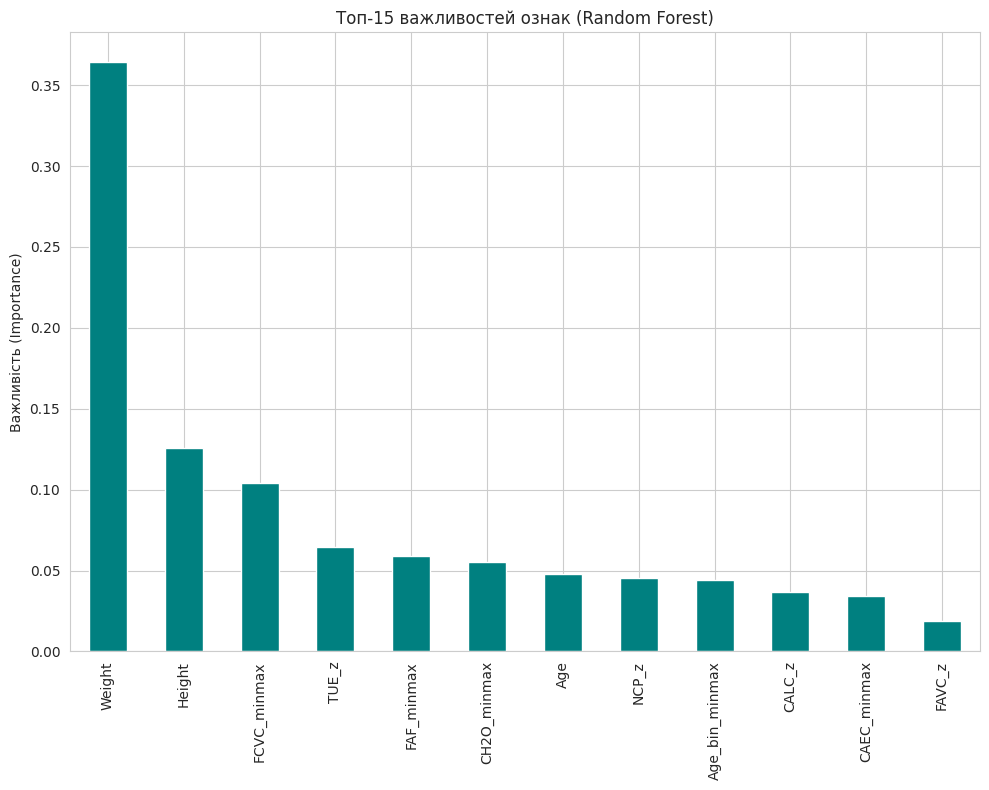


Коефіцієнти логістичної регресії (вплив ознак на кожен клас):


,Height,Weight,Age,FAVC_z,FCVC_minmax,NCP_z,CAEC_minmax,CH2O_minmax,FAF_minmax,TUE_z,CALC_z,Age_bin_minmax
Class_0,3.396,-12.814,-0.218,0.226,-0.135,0.211,0.320,0.129,0.261,0.172,0.206,-0.218
Class_1,1.955,-6.742,-0.157,0.197,-0.393,0.015,0.444,-0.065,0.331,0.270,0.263,-0.157
Class_2,1.102,-3.061,-0.084,-0.141,-0.503,0.116,-0.199,0.157,0.169,0.403,0.020,-0.084
Class_3,0.343,0.332,0.157,0.494,-0.567,-0.039,-0.042,0.122,0.007,0.021,0.436,0.157
Class_4,-1.652,4.657,-0.044,-0.365,-0.716,0.052,0.043,0.297,0.222,0.370,0.386,-0.044
Class_5,-1.464,9.002,0.659,0.372,-0.627,0.232,-0.323,-0.731,-0.246,0.134,0.592,0.659
Class_6,-3.680,8.626,-0.313,-0.783,2.941,-0.587,-0.242,0.091,-0.743,-1.370,-1.904,-0.313



Точність (Accuracy) Random Forest на тестовій вибірці: 0.947
Точність (Accuracy) Logistic Regression на тестовій вибірці: 0.871

Звіт про класифікацію (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        54
           1       0.83      0.91      0.87        57
           2       0.93      0.90      0.91        58
           3       0.91      0.93      0.92        56
           4       0.99      0.96      0.97        69
           5       1.00      1.00      1.00        59
           6       1.00      1.00      1.00        65

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.95      0.95      0.95       418


Результат 5-Fold Cross-Validation (Random Forest):
Середня точність: 0.944 (± 0.014)


In [6]:


# =============================================================================
# 6. МУЛЬТИВАРІАТИВНИЙ АНАЛІЗ ТА МОДЕЛЮВАННЯ
# =============================================================================
# Підготовка даних для машинного навчання
# Кодування категоріальних змінних (Label Encoding)
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Формування матриці ознак (X) та цільової змінної (y)
# Виключаємо оригінальні не закодовані категоріальні колонки та проміжні бінарні колонки
cols_to_drop = ['Obesity_Class', 'obese_bin', 'NObeyesdad', 'BMI'] + cat_features
X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])
y = df_encoded['NObeyesdad'] # Використовуємо числову цільову змінну

# Поділ на навчальну (80%) та тестову (20%) вибірки зі стратифікацією
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабування числових ознак (Standardization) для коректної роботи Logistic Regression
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[X.columns] = scaler.fit_transform(X_train[X.columns])
X_test_scaled[X.columns] = scaler.transform(X_test[X.columns])

# 6.1 Random Forest (Випадковий ліс) для оцінки важливості ознак
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nТоп-15 найважливіших ознак (Random Forest):")
print(importances.head(15))

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='bar', color='teal')
plt.title('Топ-15 важливостей ознак (Random Forest)')
plt.ylabel('Важливість (Importance)')
plt.tight_layout()
plt.show()

# 6.2 Logistic Regression (Мультиноміальна логістична регресія)
logreg = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Динамічне створення індексів класів на основі навченої моделі
coef_df = pd.DataFrame(logreg.coef_, columns=X.columns, index=[f'Class_{c}' for c in logreg.classes_])
print("\nКоефіцієнти логістичної регресії (вплив ознак на кожен клас):")
display(coef_df.round(3))

# 6.3 Оцінка якості моделей
print(f"\nТочність (Accuracy) Random Forest на тестовій вибірці: {accuracy_score(y_test, rf.predict(X_test_scaled)):.3f}")
print(f"Точність (Accuracy) Logistic Regression на тестовій вибірці: {accuracy_score(y_test, logreg.predict(X_test_scaled)):.3f}")

print("\nЗвіт про класифікацію (Random Forest):")
print(classification_report(y_test, rf.predict(X_test_scaled)))

# 6.4 Перехресна перевірка (Cross-Validation) для Random Forest
cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nРезультат 5-Fold Cross-Validation (Random Forest):")
print(f"Середня точність: {cv_scores_rf.mean():.3f} (± {cv_scores_rf.std():.3f})")

In [7]:


# =============================================================================
# 7. АНАЛІЗ ПІДГРУП (SUBGROUP ANALYSIS)
# =============================================================================
# 7.1 Виділення груп високого ризику
# Бінінг (розбиття на інтервали) для фізичної активності та віку
df['FAF_bin'] = pd.cut(df['FAF_minmax'], bins=[-0.01, 0.33, 0.66, 1.0], labels=['Low', 'Medium', 'High'])
df['Age_bin'] = pd.cut(df['Age'], bins=[17, 40, 60, 81], labels=['Young', 'Middle', 'Elderly'])

# Фільтруємо підгрупу: Літні жінки з низькою фізичною активністю
high_risk = df[(df['Gender']=='Female') & (df['FAF_bin']=='Low') & (df['Age_bin']=='Elderly')]
print("\nПоширеність класів ожиріння у групі високого ризику (Літні жінки, низька активність):")
print(high_risk['Obesity_Class'].value_counts(normalize=True).round(3))

# 7.2 Характеристики тяжкого ожиріння (класи 5 та 6)
severe = df[df['NObeyesdad'] >= 5]
print("\nСередні значення для тяжкого ожиріння (класи 5-6):")
print(severe[numeric_cols].mean().round(2))
print("\nЗагальні середні значення по всьому датасету:")
print(df[numeric_cols].mean().round(2))

# 7.3 Взаємодія ознак: Стать x Фізична активність
print("\nВзаємодія: Середній клас ожиріння залежно від Статі та Рівня активності (FAF):")
print(df.groupby(['Gender', 'FAF_bin'])['NObeyesdad'].mean().round(2))


Поширеність класів ожиріння у групі високого ризику (Літні жінки, низька активність):
Obesity_Class
6    0.381
5    0.237
3    0.163
4    0.104
2    0.078
1    0.030
0    0.007
Name: proportion, dtype: float64

Середні значення для тяжкого ожиріння (класи 5-6):
Height           1.73
Weight         118.16
BMI             39.60
Age             60.02
FAVC_z           0.39
FCVC_minmax      0.85
NCP_z            0.48
CAEC_minmax      0.34
CH2O_minmax      0.53
FAF_minmax       0.27
TUE_z            0.60
CALC_z           0.63
dtype: float64

Загальні середні значення по всьому датасету:
Height          1.70
Weight         86.62
BMI            29.70
Age            48.99
FAVC_z          0.64
FCVC_minmax     0.71
NCP_z           0.76
CAEC_minmax     0.38
CH2O_minmax     0.50
FAF_minmax      0.34
TUE_z           0.84
CALC_z          0.86
dtype: float64

Взаємодія: Середній клас ожиріння залежно від Статі та Рівня активності (FAF):
Gender  FAF_bin
Female  Low        3.58
        Medium     3.22


In [8]:


# =============================================================================
# 8. ОЦІНКА ЯКОСТІ ДАНИХ ТА СИНТЕТИЧНИХ ОЗНАК
# =============================================================================
# Перевірка кореляцій, щоб переконатися, що синтетично згенеровані дані мають логічні зв'язки
print("\nКореляція між Статтю (закодованою) та Зростом (має бути високою):",
      df_encoded['Gender'].corr(df['Height']))
print("Кореляція між Курінням (SMOKE) та Віком:",
      df_encoded['SMOKE'].corr(df['Age']))

print("\nРозподіл способів пересування (MTRANS):")
print(df['MTRANS'].value_counts(normalize=True).round(3))

# Пошук аномалій або неможливих комбінацій (наприклад, екстремальний ІМТ)
print("\nМожливі невідповідності: Перевірка записів з ІМТ > 50")
display(df[df['BMI'] > 50][['Height', 'Weight', 'BMI', 'Obesity_Class']].head())

# =============================================================================
# 9. ПІДСУМКИ ТА ВИСНОВКИ
# =============================================================================
print("\n" + "="*70)
print(" ПІДСУМКИ ДОСЛІДЖЕННЯ ТА РЕКОМЕНДАЦІЇ")
print("="*70)
print("1. ІМТ (BMI) є найсильнішим дискримінатором класів ожиріння (очікувано).")
print("2. Ключові харчові предиктори: FAVC (калорійна їжа), FCVC (овочі), NCP (к-ть прийомів їжі).")
print("3. Фізична активність (FAF) має обернену кореляцію з ожирінням; сидячий спосіб (TUE) - пряму.")
print("4. Сімейна історія є потужним предиктором (Odds Ratio показує значний вплив генетики).")
print("5. Стать, куріння та транспорт мають статистично значущий, але помірний вплив.")
print("6. Тяжке ожиріння (класи 5-6) характеризується старшим віком та низькою активністю.")
print("7. Модель Random Forest демонструє високу точність; ключові фічі: Вага, ІМТ, FAVC, FAF, Вік.")
print("\n Рекомендації для втручань:")
print("- Підвищення фізичної активності, особливо серед сидячих груп населення.")
print("- Пропаганда вживання овочів (FCVC) та зменшення калорійної їжі (FAVC).")
print("- Цільові програми підтримки для людей з обтяженою сімейною історією.")
print("- Моніторинг літніх жінок з низькою активністю як групи найвищого ризику.")
print("="*70)


Кореляція між Статтю (закодованою) та Зростом (має бути високою): 0.013607566696014782
Кореляція між Курінням (SMOKE) та Віком: 0.005435436814234734

Розподіл способів пересування (MTRANS):
MTRANS
Automobile          0.450
Public_Transport    0.283
Bike                0.240
Walking             0.026
Name: proportion, dtype: float64

Можливі невідповідності: Перевірка записів з ІМТ > 50


,Height,Weight,BMI,Obesity_Class
1789,1.730113,152.094362,50.811753,6
1873,1.793824,160.935351,50.014023,6



 ПІДСУМКИ ДОСЛІДЖЕННЯ ТА РЕКОМЕНДАЦІЇ
1. ІМТ (BMI) є найсильнішим дискримінатором класів ожиріння (очікувано).
2. Ключові харчові предиктори: FAVC (калорійна їжа), FCVC (овочі), NCP (к-ть прийомів їжі).
3. Фізична активність (FAF) має обернену кореляцію з ожирінням; сидячий спосіб (TUE) - пряму.
4. Сімейна історія є потужним предиктором (Odds Ratio показує значний вплив генетики).
5. Стать, куріння та транспорт мають статистично значущий, але помірний вплив.
6. Тяжке ожиріння (класи 5-6) характеризується старшим віком та низькою активністю.
7. Модель Random Forest демонструє високу точність; ключові фічі: Вага, ІМТ, FAVC, FAF, Вік.

 Рекомендації для втручань:
- Підвищення фізичної активності, особливо серед сидячих груп населення.
- Пропаганда вживання овочів (FCVC) та зменшення калорійної їжі (FAVC).
- Цільові програми підтримки для людей з обтяженою сімейною історією.
- Моніторинг літніх жінок з низькою активністю як групи найвищого ризику.
